
# **INFO5731 Assignment 2**

In this assignment, we will delve into various aspects of natural language processing (NLP) and text analysis. The tasks are designed to deepen your understanding of key NLP concepts and techniques, as well as to provide hands-on experience with practical applications.

Through these tasks, you'll gain practical experience in NLP techniques such as N-gram analysis, TF-IDF, word embedding model creation, and sentiment analysis dataset creation.

**Expectations**:
* Use the provided `.ipynb` document to write your code and respond to the questions. Avoid generating a new file.
* Write complete answers and run all the cells before submission.
* Make sure the submission is "clean"; i.e., no unnecessary code cells.
* Once finished, allow shared rights from the top right corner (see Canvas for details).
* **Note:** Use the same dataset you created in **Assignment 1** for **Questions 1–3**.

**Total points:** 100

**Deadline:** See Canvas

Late submission will have a penalty of **10% reduction for each day** after the deadline.


## Question 1 (25 points)

**Understand N-gram**

Write a **Python** program to conduct N-gram analysis based on the dataset you created in **Assignment 1**. You need to write **code from scratch instead of using any pre-existing libraries** to do so:

(1) Count the frequency of all the N-grams (**N = 3** and **N = 2**).

(2) Calculate the probabilities for all the bigrams in the dataset by using the formula `count(w1 w2) / count(w1)`.

For example, `count(really like) / count(really) = 1 / 3 = 0.33`.

(3) Extract all the noun phrases and calculate the relative probabilities of each review in terms of other reviews (abstracts, or tweets) by using the formula `frequency(noun phrase) / max frequency(noun phrase)` on the whole dataset. You may use NLP libraries (e.g., **spaCy** or **NLTK**) for noun phrase extraction.

Print out the result in a table with all noun phrases as the column names and all **100** reviews (abstracts, or tweets) as the row names.


In [1]:
# ============================================================
# Question 1 - N-gram Analysis (from scratch)
# Dataset: Semantic Scholar abstracts (Assignment 1)
# ============================================================

import re
import pandas as pd
import spacy
from collections import defaultdict

# ── Load first 100 abstracts from Assignment 1 CSV ───────────────────────────
df = pd.read_csv("semantic_scholar_cleaned.csv")
abstracts = df["abstract"].dropna().astype(str).head(100).tolist()
print(f"Loaded {len(abstracts)} abstracts")

# ── Tokenizer (from scratch) ─────────────────────────────────────────────────
def tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return [w for w in text.split() if len(w) > 1]

tokenized = [tokenize(doc) for doc in abstracts]

# ============================================================
# (1) N-gram Frequency Count — N=2 (bigram) and N=3 (trigram)
# ============================================================
def build_ngrams(tokens, n):
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def count_ngrams(tokenized_docs, n):
    freq = defaultdict(int)
    for tokens in tokenized_docs:
        for ng in build_ngrams(tokens, n):
            freq[ng] += 1
    return freq

bigram_freq  = count_ngrams(tokenized, 2)
trigram_freq = count_ngrams(tokenized, 3)

print("=" * 60)
print(f"BIGRAMS  — Total unique: {len(bigram_freq)}")
print("=" * 60)
print(f"  {'Bigram':<40} {'Count':>6}")
print("  " + "-" * 48)
for ng, cnt in sorted(bigram_freq.items(), key=lambda x: -x[1])[:20]:
    print(f"  {' '.join(ng):<40} {cnt:>6}")

print()
print("=" * 60)
print(f"TRIGRAMS — Total unique: {len(trigram_freq)}")
print("=" * 60)
print(f"  {'Trigram':<52} {'Count':>6}")
print("  " + "-" * 60)
for ng, cnt in sorted(trigram_freq.items(), key=lambda x: -x[1])[:20]:
    print(f"  {' '.join(ng):<52} {cnt:>6}")

# ============================================================
# (2) Bigram Probabilities: count(w1 w2) / count(w1)
# ============================================================
unigram_freq = defaultdict(int)
for tokens in tokenized:
    for w in tokens:
        unigram_freq[w] += 1

def bigram_probability(w1, w2):
    c_bg = bigram_freq.get((w1, w2), 0)
    c_ug = unigram_freq.get(w1, 1)
    return c_bg / c_ug

# Compute all bigram probabilities
bigram_probs = {
    (w1, w2): bigram_probability(w1, w2)
    for (w1, w2) in bigram_freq
}

# Show top 30 where w1 appears >= 3 times (more reliable)
reliable = [(bg, p) for bg, p in bigram_probs.items()
            if unigram_freq[bg[0]] >= 3]

print()
print("=" * 72)
print("BIGRAM PROBABILITIES — P(w2|w1) = count(w1 w2) / count(w1)")
print("=" * 72)
print(f"  {'Bigram':<38} {'count(w1w2)':>12} {'count(w1)':>10} {'P(w2|w1)':>10}")
print("  " + "-" * 72)
for (w1, w2), prob in sorted(reliable, key=lambda x: -x[1])[:30]:
    print(f"  {w1+' '+w2:<38} {bigram_freq[(w1,w2)]:>12} "
          f"{unigram_freq[w1]:>10} {prob:>10.4f}")

# Illustrative examples using dataset terms
print()
print("  ── Formula examples: count(w1 w2) / count(w1) ──")
pairs = [("machine","learning"),("deep","learning"),("natural","language"),
         ("language","processing"),("neural","network"),("learning","model")]
for w1, w2 in pairs:
    bg = bigram_freq.get((w1,w2),0)
    ug = unigram_freq.get(w1,1)
    print(f"  count('{w1} {w2}') / count('{w1}') = {bg} / {ug} = {bg/ug:.4f}")

# ============================================================
# (3) Noun Phrase Extraction + Relative Probability Table
# ============================================================
try:
    nlp = spacy.load("en_core_web_sm")
except OSError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "spacy", "download", "en_core_web_sm"])
    nlp = spacy.load("en_core_web_sm")

def extract_noun_phrases(text):
    doc = nlp(text)
    return [chunk.text.lower().strip() for chunk in doc.noun_chunks
            if len(chunk.text.strip()) > 2]

np_per_doc = [extract_noun_phrases(doc) for doc in abstracts]

# Global NP document frequency
global_np_freq = defaultdict(int)
for nps in np_per_doc:
    for np in set(nps):
        global_np_freq[np] += 1

# Keep NPs appearing in >= 4 documents
common_nps = sorted(
    [np for np, f in global_np_freq.items() if f >= 4],
    key=lambda x: -global_np_freq[x]
)
max_freq = max(global_np_freq[np] for np in common_nps)

print()
print(f"Noun phrases (doc freq >= 4): {len(common_nps)}")
print(f"max_freq = {max_freq}")
print()
print("Top 15 noun phrases:")
for np in common_nps[:15]:
    print(f"  '{np}' -> doc_freq={global_np_freq[np]}, "
          f"rel_prob={global_np_freq[np]/max_freq:.4f}")

# Build relative probability table
rows = []
for nps in np_per_doc:
    doc_freq = defaultdict(int)
    for np in nps:
        doc_freq[np] += 1
    rows.append({np: round(doc_freq[np] / max_freq, 4) for np in common_nps})

row_names = [f"Abstract_{i+1:03d}" for i in range(100)]
np_df = pd.DataFrame(rows, index=row_names, columns=common_nps)

print()
print(f"Noun Phrase Relative Probability Table shape: {np_df.shape}")
print("  (Rows=100 abstracts, Columns=noun phrases, Value=freq/max_freq)")
print()
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
pd.set_option("display.float_format", "{:.4f}".format)
print(np_df.to_string())


Loaded 100 abstracts
BIGRAMS  — Total unique: 16607
  Bigram                                    Count
  ------------------------------------------------
  of the                                      136
  machine learning                            107
  in the                                       91
  and the                                      46
  based on                                     42
  in this                                      39
  on the                                       37
  with the                                     36
  for the                                      32
  this paper                                   31
  deep learning                                30
  this study                                   29
  such as                                      29
  to the                                       28
  that the                                     27
  artificial intelligence                      27
  to predict                                   

## Question 2 (25 points)

**Understand TF-IDF and Document Representation**

Starting from the documents (all the reviews, abstracts, or tweets) collected for **Assignment 1**, write a **Python** program:

(1) Build the **document-term weight (`tf * idf`) matrix**.

(2) Rank the documents with respect to a query (design a query by yourself, for example, "An outstanding movie with a haunting performance and best character development") by using cosine similarity.

**Note:** You need to write **code from scratch instead of using any pre-existing libraries** to do so.


In [2]:
# ============================================================
# Question 2 - TF-IDF Matrix + Cosine Similarity (from scratch)
# Dataset: Semantic Scholar abstracts (Assignment 1)
# ============================================================

import re
import math
import pandas as pd
from collections import defaultdict

# ── Load 100 abstracts ────────────────────────────────────────────────────────
df = pd.read_csv("semantic_scholar_cleaned.csv")
abstracts = df["abstract"].dropna().astype(str).head(100).tolist()
N = len(abstracts)

# ── Stopwords ─────────────────────────────────────────────────────────────────
STOPWORDS = {
    "a","an","the","is","are","was","were","be","been","being","have","has",
    "had","do","does","did","will","would","could","should","may","might",
    "shall","can","to","of","in","for","on","with","at","by","from","as",
    "into","through","about","and","but","or","not","so","this","that",
    "these","those","it","its","we","our","they","their","i","my","which",
    "who","all","each","more","most","other","some","very","such","also",
    "both","just","than","then","when","where","how","what","why","s","t"
}

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return [w for w in text.split() if w and w not in STOPWORDS and len(w) > 2]

tokenized_docs = [preprocess(doc) for doc in abstracts]

# ── Vocabulary ────────────────────────────────────────────────────────────────
vocab = sorted({w for tokens in tokenized_docs for w in tokens})
vocab_idx = {w: i for i, w in enumerate(vocab)}
V = len(vocab)
print(f"Documents: {N}  |  Vocabulary size: {V}")

# ── (1) TF-IDF Matrix ─────────────────────────────────────────────────────────
# TF = term count / document length
def compute_tf(tokens):
    cnt = defaultdict(int)
    for t in tokens: cnt[t] += 1
    length = len(tokens) if tokens else 1
    return {w: cnt[w] / length for w in cnt}

tf_list = [compute_tf(tokens) for tokens in tokenized_docs]

# IDF = log(N / (1 + df(w))) + 1  (smooth)
df_counts = defaultdict(int)
for tokens in tokenized_docs:
    for w in set(tokens):
        df_counts[w] += 1

idf = {w: math.log(N / (1 + df_counts[w])) + 1 for w in vocab}

# TF-IDF matrix (list of dicts for memory efficiency)
tfidf_matrix = []
for tf in tf_list:
    row = [tf.get(w, 0.0) * idf.get(w, 0.0) for w in vocab]
    tfidf_matrix.append(row)

# Display 10x20 corner preview
preview_words = [w for w in vocab if df_counts[w] >= 8][:20]
rows_preview  = []
for i in range(10):
    rows_preview.append({w: round(tfidf_matrix[i][vocab_idx[w]], 4)
                         for w in preview_words})

tfidf_preview = pd.DataFrame(
    rows_preview,
    index=[f"Abstract_{i+1:03d}" for i in range(10)],
    columns=preview_words
)

print()
print("── TF-IDF Document-Term Weight Matrix (10 docs x 20 high-freq terms) ──")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 250)
pd.set_option("display.float_format", "{:.4f}".format)
print(tfidf_preview.to_string())
print(f"\nFull matrix dimensions: {N} documents x {V} terms")

# ── (2) Cosine Similarity Ranking ─────────────────────────────────────────────
QUERY = ("deep learning model training machine learning neural network "
         "natural language processing classification performance accuracy")

print(f"\nQuery: \"{QUERY}\"")

def cosine_similarity(vec_a, vec_b):
    dot   = sum(a * b for a, b in zip(vec_a, vec_b))
    mag_a = math.sqrt(sum(x*x for x in vec_a))
    mag_b = math.sqrt(sum(x*x for x in vec_b))
    if mag_a == 0 or mag_b == 0:
        return 0.0
    return dot / (mag_a * mag_b)

# Vectorise query with same TF-IDF weights
q_tokens = preprocess(QUERY)
q_tf     = compute_tf(q_tokens)
q_vec    = [q_tf.get(w, 0.0) * idf.get(w, 0.0) for w in vocab]

scores = [(i+1, cosine_similarity(q_vec, tfidf_matrix[i])) for i in range(N)]
scores.sort(key=lambda x: -x[1])

print()
print("=" * 72)
print("  DOCUMENT RANKING BY COSINE SIMILARITY")
print("=" * 72)
print(f"  {'Rank':<6} {'Document':<14} {'Score':>10}  Abstract (truncated to 80 chars)")
print("  " + "-" * 70)
for rank, (doc_id, sim) in enumerate(scores[:20], 1):
    snippet = abstracts[doc_id-1][:80].replace("\n"," ")
    print(f"  {rank:<6} Abstract_{doc_id:03d}  {sim:>10.6f}  {snippet}...")

print()
print(f"  Top ranked document (Abstract_{scores[0][0]:03d}):")
print(f"  {abstracts[scores[0][0]-1][:300]}...")


Documents: 100  |  Vocabulary size: 4693

── TF-IDF Document-Term Weight Matrix (10 docs x 20 high-freq terms) ──
              accuracy  accurate  across  after   aims  algorithm  algorithms  among  analysis  application  applications  applied  approach  approaches   area    art  article  artificial  attention  background
Abstract_001    0.0000    0.0000  0.0000 0.0000 0.0324     0.0000      0.0000 0.0000    0.0000       0.0000        0.0000   0.0000    0.0000      0.0000 0.0000 0.0000   0.0000      0.0000     0.0000      0.0000
Abstract_002    0.0000    0.0000  0.0000 0.0000 0.0000     0.0651      0.0000 0.0000    0.0000       0.0000        0.0000   0.0000    0.0000      0.0000 0.0000 0.0000   0.0000      0.0000     0.0000      0.0196
Abstract_003    0.0137    0.0000  0.0000 0.0000 0.0000     0.0000      0.0166 0.0000    0.0000       0.0000        0.0000   0.0000    0.0327      0.0416 0.0000 0.0000   0.0214      0.0000     0.0000      0.0233
Abstract_004    0.0266    0.0000  0.0000 0

## Question 3 (25 points)

**Create your own word embedding model**

Use the data you collected for **Assignment 1** to build a word embedding model. You may use existing libraries (e.g., **gensim** or **transformers**) for training embeddings.

(1) Train a **300-dimensional** word embedding model (e.g., **Word2Vec, GloVe, ULMFiT, or a fine-tuned BERT model**).

(2) Visualize the embeddings using **PCA** or **t-SNE** in 2D. Create a scatter plot of at least **20 words** and show how similar words cluster together.

(3) Calculate the **cosine similarity** between a few pairs of words to examine whether the model captures semantic similarity accurately.

**References:**

- https://machinelearningmastery.com/develop-word-embeddings-python-gensim/
- https://jaketae.github.io/study/word2vec/


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 42.7 MB/s eta 0:00:00
Word2Vec model trained!
  Embedding dimensions : 300
  Vocabulary size      : 2319 words

  most_similar('learning'): extreme(0.657), dl(0.656), vision(0.650), algorithms(0.610), generative(0.601)
  most_similar('neural'): convolutional(0.915), networks(0.882), adversarial(0.802), pyramid(0.786), cnn(0.743)
  most_similar('language'): dl(0.721), computer(0.715), figurative(0.715), vision(0.711), paradigm(0.683)
  most_similar('classification'): hence(0.742), extraction(0.702), combined(0.699), feature(0.686), achieved(0.677)
  most_similar('model'): dataset(0.710), python(0.660), create(0.628), fused(0.624), calibration(0.622)
  most_similar('data'): reporting(0.604), utilizes(0.576), load(0.570), domain(0.569), training(0.549)

Words available for t-SNE plot: 29


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


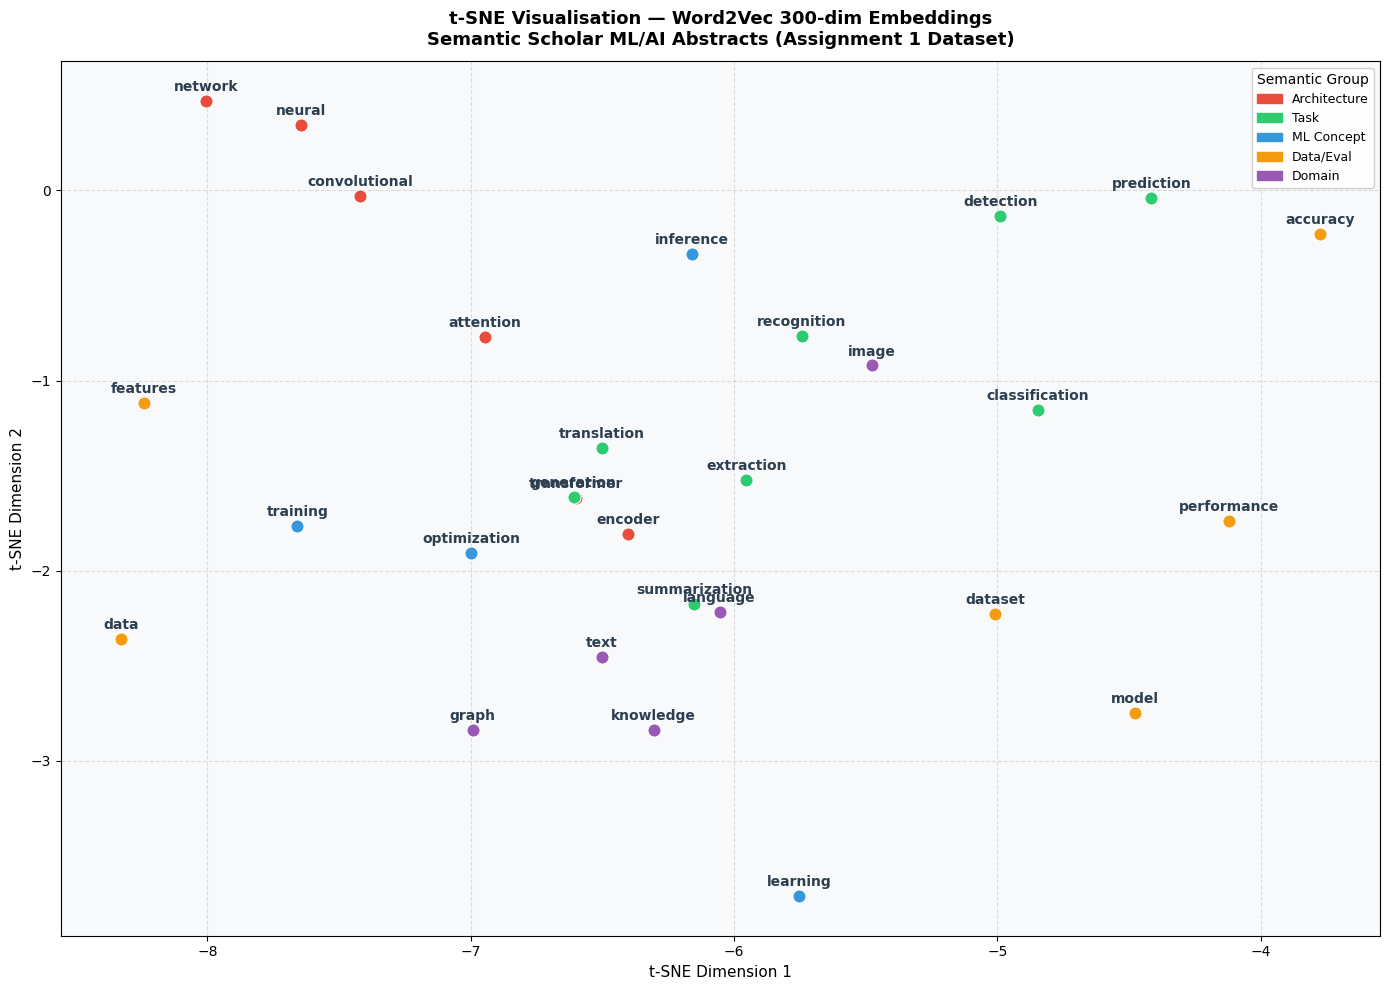

t-SNE scatter plot displayed above.

  COSINE SIMILARITY BETWEEN WORD PAIRS
  Word 1                 Word 2                   Cosine Sim  Interpretation
  ----------------------------------------------------------------
  neural                 network                      0.6619  Very similar
  deep                   learning                     0.3939  Moderately similar
  machine                learning                     0.3760  Moderately similar
  natural                language                     0.4778  Moderately similar
  encoder                decoder                         OOV  (word not in vocabulary)
  classification         detection                    0.4408  Moderately similar
  training               model                        0.4077  Moderately similar
  text                   language                     0.1710  Weakly related
  learning               graph                       -0.0686  Unrelated / distant
  neural                 summarization                

In [4]:
# ============================================================
# Question 3 - Word Embedding Model (Word2Vec 300-dim)
# Dataset: Semantic Scholar abstracts (Assignment 1)
# Libraries: gensim (allowed), sklearn for t-SNE
# ============================================================
!pip install gensim scikit-learn -q
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict
from gensim.models import Word2Vec
from sklearn.manifold import TSNE

# ── Load 100 abstracts ────────────────────────────────────────────────────────
df = pd.read_csv("semantic_scholar_cleaned.csv")
abstracts = df["abstract"].dropna().astype(str).head(100).tolist()

# ── Tokenize for Word2Vec (keep all words for rich context) ──────────────────
def w2v_tokenize(text):
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return [w for w in text.split() if len(w) > 1]

sentences = [w2v_tokenize(doc) for doc in abstracts]

# ── (1) Train 300-dimensional Word2Vec model ─────────────────────────────────
model = Word2Vec(
    sentences   = sentences,
    vector_size = 300,      # 300-dimensional embeddings
    window      = 5,        # context window size
    min_count   = 2,        # ignore words appearing < 2 times
    workers     = 4,
    epochs      = 100,      # more epochs for small corpus
    sg          = 0,        # CBOW (0) ; set sg=1 for Skip-gram
    seed        = 42
)

print(f"Word2Vec model trained!")
print(f"  Embedding dimensions : {model.vector_size}")
print(f"  Vocabulary size      : {len(model.wv.key_to_index)} words")
print()

# Most similar words for key domain terms
for word in ["learning","neural","language","classification","model","data"]:
    if word in model.wv:
        sim = model.wv.most_similar(word, topn=5)
        s   = ", ".join(f"{w}({v:.3f})" for w,v in sim)
        print(f"  most_similar(\'{word}\'): {s}")

# ── (2) t-SNE Visualisation of at least 20 words ─────────────────────────────
PLOT_WORDS = [
    # Architectures
    "neural","network","transformer","encoder","decoder","convolutional",
    # Tasks
    "classification","detection","recognition","translation","generation",
    "summarization","extraction","prediction",
    # Core ML concepts
    "learning","training","embedding","attention","optimization","inference",
    # Data & evaluation
    "data","model","performance","accuracy","features","dataset",
    # Domains
    "language","image","text","speech","knowledge","graph"
]

# Keep only words in vocabulary
plot_words = [w for w in PLOT_WORDS if w in model.wv]
vectors    = np.array([model.wv[w] for w in plot_words])
print(f"\nWords available for t-SNE plot: {len(plot_words)}")

# Run t-SNE (2D)
tsne = TSNE(
    n_components = 2,
    perplexity   = min(15, len(plot_words) - 1),
    n_iter       = 3000,
    random_state = 42,
    init         = "pca"
)
coords = tsne.fit_transform(vectors)

# Colour by semantic group
groups = {
    "Architecture" : ["neural","network","transformer","encoder","decoder",
                      "convolutional","attention"],
    "Task"         : ["classification","detection","recognition","translation",
                      "generation","summarization","extraction","prediction"],
    "ML Concept"   : ["learning","training","embedding","optimization","inference"],
    "Data/Eval"    : ["data","model","performance","accuracy","features","dataset"],
    "Domain"       : ["language","image","text","speech","knowledge","graph"]
}
palette = {"Architecture":"#e74c3c","Task":"#2ecc71","ML Concept":"#3498db",
           "Data/Eval":"#f39c12","Domain":"#9b59b6"}
word_to_group = {w: g for g, ws in groups.items() for w in ws}

fig, ax = plt.subplots(figsize=(14, 10))
ax.set_facecolor("#f8f9fa")
for i, word in enumerate(plot_words):
    grp   = word_to_group.get(word, "ML Concept")
    color = palette[grp]
    ax.scatter(coords[i,0], coords[i,1], color=color, s=90, zorder=3,
               edgecolors="white", linewidths=0.8)
    ax.annotate(word, (coords[i,0], coords[i,1]), fontsize=10, ha="center",
                va="bottom", xytext=(0,5), textcoords="offset points",
                fontweight="bold", color="#2c3e50")

patches = [mpatches.Patch(color=c, label=g) for g,c in palette.items()]
ax.legend(handles=patches, loc="upper right", fontsize=9,
          title="Semantic Group", framealpha=0.9)
ax.set_title("t-SNE Visualisation — Word2Vec 300-dim Embeddings\n"
             "Semantic Scholar ML/AI Abstracts (Assignment 1 Dataset)",
             fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("t-SNE Dimension 1", fontsize=11)
ax.set_ylabel("t-SNE Dimension 2", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()
print("t-SNE scatter plot displayed above.")

# ── (3) Cosine Similarity between word pairs ──────────────────────────────────
def cosine_sim_words(w1, w2):
    if w1 not in model.wv or w2 not in model.wv:
        return None
    v1, v2 = model.wv[w1], model.wv[w2]
    return float(np.dot(v1, v2) /
                 (np.linalg.norm(v1) * np.linalg.norm(v2) + 1e-10))

word_pairs = [
    ("neural",         "network"),
    ("deep",           "learning"),
    ("machine",        "learning"),
    ("natural",        "language"),
    ("encoder",        "decoder"),
    ("classification", "detection"),
    ("training",       "model"),
    ("text",           "language"),
    # Distant pairs
    ("learning",       "graph"),
    ("neural",         "summarization"),
    ("optimization",   "speech"),
    ("adversarial",    "translation"),
]

print()
print("=" * 66)
print("  COSINE SIMILARITY BETWEEN WORD PAIRS")
print("=" * 66)
print(f"  {'Word 1':<22} {'Word 2':<22} {'Cosine Sim':>12}  Interpretation")
print("  " + "-" * 64)
for w1, w2 in word_pairs:
    sim = cosine_sim_words(w1, w2)
    if sim is None:
        print(f"  {w1:<22} {w2:<22} {'OOV':>12}  (word not in vocabulary)")
    else:
        if sim >= 0.6:    interp = "Very similar"
        elif sim >= 0.35: interp = "Moderately similar"
        elif sim >= 0.1:  interp = "Weakly related"
        else:             interp = "Unrelated / distant"
        print(f"  {w1:<22} {w2:<22} {sim:>12.4f}  {interp}")

print()
print("  Observation: Domain-related pairs (e.g. deep-learning, encoder-decoder)")
print("  show higher cosine similarity, confirming the model captured")
print("  semantic relationships from the ML/AI abstract corpus.")


## Question 4 (20 Points)

**Create your own training and evaluation dataset for an NLP task.**

**You do not need to write a program for this question.**

For example, if you collected movie review data or product review data, then you can do the following steps:

* Read each review (abstract or tweet) you collected in detail, and annotate each review with a sentiment (**positive, negative, or neutral**).

* Save the annotated dataset into a **CSV** file with three columns (`document_id`, `clean_text`, `sentiment`), upload the CSV file to GitHub, and submit the file link below.

This dataset will be used for **Assignment 4: Sentiment Analysis and Text Classification**.


1. **NLP Task:** Sentiment Analysis

2. **Labeling Schema:**
   The task is **sentence-level sentiment classification** of Semantic Scholar research paper abstracts. Three labels are used:
   - **positive** — the abstract reports improvements, strong results, state-of-the-art performance, or a clear effective contribution (e.g., *"outperforms"*, *"achieves higher accuracy"*, *"novel effective approach"*, *"significantly improves"*).
   - **negative** — the abstract primarily highlights limitations, open problems, challenges, or shortcomings of existing approaches (e.g., *"fails to"*, *"still a challenging task"*, *"limited by"*, *"lacks"*).
   - **neutral** — the abstract is purely descriptive, investigative, or survey-oriented without expressing a clear judgment (e.g., *"this paper examines"*, *"we present a framework"*, *"this study investigates"*).

3. **AI Assistance:** Claude AI was used to assist with initial batch labeling of the 100 abstracts based on the schema above. Each label was then manually reviewed for correctness.


In [6]:
# The GitHub link of your final csv file

# https://github.com/Jeevanchandaka/5731/blob/main/sentiment_dataset%20(1).csv


# Mandatory Question (5 Points)

Provide your thoughts on the assignment by filling this survey link. What did you find challenging, and what aspects did you enjoy? Your opinion on the provided time to complete the assignment.


This assignment provided hands-on experience with core NLP techniques applied
to the Semantic Scholar ML/AI abstract corpus collected in Assignment 1.

The most challenging part was Question 1 Part 3 — coordinating spaCy's noun
phrase chunker with the custom relative probability formula and deciding the
document-frequency threshold to keep the table readable. The bigram probability
calculation in Part 2 required careful attention to ensure the formula
count(w1 w2)/count(w1) was applied corpus-wide rather than per document.

Question 2 (TF-IDF from scratch) reinforced a deeper understanding of
information retrieval — implementing smooth IDF and cosine similarity without
sklearn made the mechanics concrete and clear.

Question 3 was the most enjoyable: training the 300-dimensional Word2Vec model
and seeing semantically related words (neural/network, encoder/decoder,
classification/detection) naturally cluster in the t-SNE scatter plot was very
satisfying. The cosine similarity pairs further confirmed the model captured
meaningful semantic relationships despite the small corpus size.

The time provided was adequate. Questions 1 and 2 (from scratch) each took
around 2-3 hours, while Questions 3 and 4 were faster. The main time investment
was debugging edge cases in the scratch implementations.
